# 05 · Departure functions and fugacity

Ideal-gas enthalpies and entropies (notebook 01) are easy; real-gas ones follow by adding a **departure
function** - the difference between the real fluid and the ideal gas at the same $T$ and $p$ - which an equation of
state supplies. The same equation supplies the **fugacity**, the "effective pressure" that replaces $p$ in
equilibrium calculations. Both are needed for compressors, expanders and heat exchangers handling real gases.

**What you will learn**
- compute real-gas enthalpy and entropy with departure functions
- analyse compressors and expanders handling real gases
- explain fugacity and the fugacity coefficient
- relate fugacity to compression work

**Before you start:** notebooks 01 and 04  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engthermo import eos, idealgas
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Departure functions from the Peng-Robinson equation
$H = H^{ig}(T) + H^R(T, p)$ and $S = S^{ig}(T, p) + S^R(T, p)$. The departures vanish as $p \to 0$:

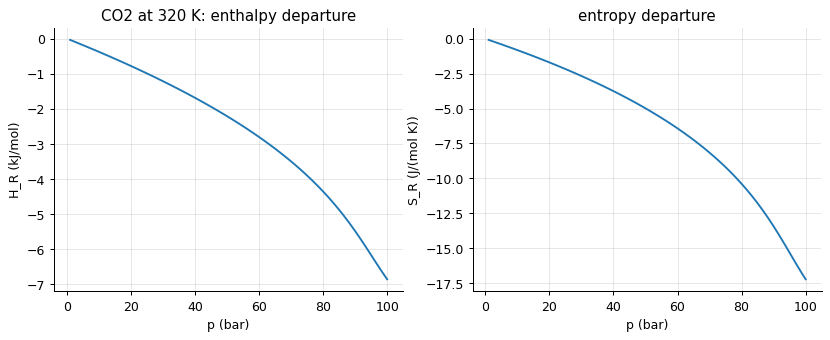

at 50 bar: H_R = -2.21 kJ/mol (compare with the ideal-gas enthalpy change for 50 K: 1.96 kJ/mol), S_R = -4.98 J/(mol K)


In [2]:
T = 320.0
pp = np.linspace(1e5, 100e5, 60)
HR = [eos.solve("pr", "CO2", T, p, "stable")["H_R"] for p in pp]
SR = [eos.solve("pr", "CO2", T, p, "stable")["S_R"] for p in pp]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(pp / 1e5, np.array(HR) / 1e3); a1.set(xlabel="p (bar)", ylabel="H_R (kJ/mol)", title="CO2 at 320 K: enthalpy departure")
a2.plot(pp / 1e5, SR); a2.set(xlabel="p (bar)", ylabel="S_R (J/(mol K))", title="entropy departure"); plt.show()
r = eos.solve("pr", "CO2", T, 50e5)
print(f"at 50 bar: H_R = {r['H_R']/1e3:.2f} kJ/mol (compare with the ideal-gas enthalpy change for 50 K: "
      f"{idealgas.enthalpy_change('CO2', T, T + 50)/1e3:.2f} kJ/mol), S_R = {r['S_R']:.2f} J/(mol K)")

Both departures are negative: attractive forces lower the enthalpy (energy is needed to pull the molecules
apart) and the entropy (the molecules are more constrained). At 50 bar the enthalpy departure of CO$_2$ is
comparable to the effect of a 50 K temperature change - not a small correction.

## A real-gas compressor
The last stage of a CO$_2$ pipeline compressor takes the gas from 40 bar and 300 K to 80 bar - close to the
critical point (304 K, 74 bar), where real-gas effects are largest. An isentropic compressor keeps
$S = S^{ig} + S^R$ constant:

In [3]:
T1, p1, p2 = 300.0, 40e5, 80e5
s1 = idealgas.entropy("CO2", T1, p1) + eos.solve("pr", "CO2", T1, p1)["S_R"]
f = lambda T: idealgas.entropy("CO2", T, p2) + eos.solve("pr", "CO2", T, p2, "stable")["S_R"] - s1
T2 = optimize.brentq(f, T1, 900.0)
h1 = idealgas.enthalpy("CO2", T1) + eos.solve("pr", "CO2", T1, p1)["H_R"]
h2 = idealgas.enthalpy("CO2", T2) + eos.solve("pr", "CO2", T2, p2, "stable")["H_R"]
T2_ig = idealgas.isentropic_T("CO2", T1, p1, p2)
w_ig = idealgas.enthalpy_change("CO2", T1, T2_ig)
print(f"real gas (PR): outlet {T2:.1f} K, work {(h2 - h1)/1e3:.3f} kJ/mol")
print(f"ideal gas:     outlet {T2_ig:.1f} K, work {w_ig/1e3:.3f} kJ/mol  ({w_ig/(h2 - h1) - 1:+.1%})")

real gas (PR): outlet 358.7 K, work 1.419 kJ/mol
ideal gas:     outlet 348.9 K, work 1.868 kJ/mol  (+31.6%)


The ideal-gas model overestimates the work by a third: the attractive forces that lower $Z$ also lower the
enthalpy of the compressed gas, so less shaft work is needed. Yet the real gas leaves *hotter*: the entropy
departure is more negative at 80 bar than at 40 bar, so the ideal-gas part of the entropy - and with it the
temperature - must rise more to keep the total entropy constant. The lower work comes from the enthalpy
departure at the outlet, not from a lower temperature. For a capture plant compressing thousands of tonnes a
day, a third of the last-stage motor is a very real number.

## Fugacity: the effective pressure
The fugacity $f = \phi p$ replaces the pressure in every equilibrium criterion for real fluids. It equals $p$
for an ideal gas; the fugacity coefficient $\phi$ comes from the equation of state:

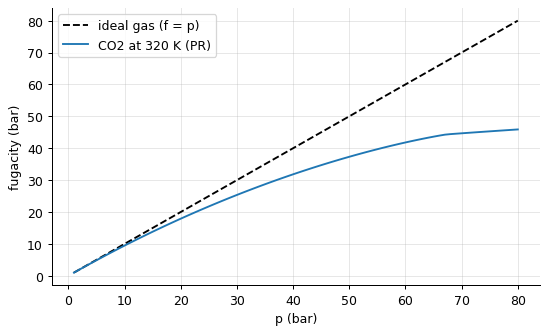

 10 bar: phi = 0.947, f = 9.5 bar
 40 bar: phi = 0.796, f = 31.8 bar
 80 bar: phi = 0.574, f = 45.9 bar


In [4]:
pp = np.linspace(1e5, 80e5, 80)
phi = [eos.solve("pr", "CO2", T1, p, "stable")["phi"] for p in pp]
plt.plot(pp / 1e5, pp / 1e5, "k--", label="ideal gas (f = p)"); plt.plot(pp / 1e5, np.array(phi) * pp / 1e5, label="CO2 at 320 K (PR)")
plt.xlabel("p (bar)"); plt.ylabel("fugacity (bar)"); plt.legend(); plt.show()
for p in (10e5, 40e5, 80e5):
    print(f"{p/1e5:3.0f} bar: phi = {eos.solve('pr', 'CO2', T1, p, 'stable')['phi']:.3f}, f = {eos.solve('pr', 'CO2', T1, p, 'stable')['phi'] * p/1e5:.1f} bar")

At 80 bar the fugacity is only 54 bar: the molecules "feel" two thirds of the pressure, because their mutual
attraction does part of the confining. Fugacity has a direct physical meaning too - the work of isothermal,
reversible compression is $RT\ln(f_2/f_1)$:

In [5]:
from scipy import integrate
f1, f2 = eos.solve("pr", "CO2", T1, 1e5)["phi"] * 1e5, eos.solve("pr", "CO2", T1, 60e5)["phi"] * 60e5
w_iso = R * T1 * np.log(f2 / f1)
w_num = integrate.quad(lambda p: eos.solve("pr", "CO2", T1, p, "stable")["V"], 1e5, 60e5, limit=200)[0]
print(f"isothermal compression work 1 -> 60 bar: RT ln(f2/f1) = {w_iso/1e3:.3f} kJ/mol; integral V dp = {w_num/1e3:.3f} kJ/mol; "
      f"ideal gas RT ln(p2/p1) = {R*T1*np.log(60)/1e3:.3f} kJ/mol")

isothermal compression work 1 -> 60 bar: RT ln(f2/f1) = 9.325 kJ/mol; integral V dp = 9.325 kJ/mol; ideal gas RT ln(p2/p1) = 10.213 kJ/mol


The three routes agree where they should: fugacity is defined precisely so that $RT\,d\ln f = V\,dp$ at
constant temperature. Isothermal compression needs far less work than adiabatic - which is why multistage
compressors with intercoolers (notebook 01) approach it.

## Inside the algorithm: the enthalpy departure of the Peng-Robinson equation
$H^R/RT = Z - 1 + \left(\frac{d\ln\alpha}{d\ln T} - 1\right) q\,I$ with $q = a/(bRT)$ and
$I = \frac{1}{\sigma - \epsilon}\ln\frac{Z + \sigma B}{Z + \epsilon B}$ (Smith, Van Ness & Abbott, Eq. 6.66):

In [6]:
prm = eos.parameters("pr", "CO2", 320.0)
r = eos.solve("pr", "CO2", 320.0, 50e5)
Bq = prm["b"] * 50e5 / (R * 320.0); q = prm["a"] / (prm["b"] * R * 320.0)
I = np.log((r["Z"] + prm["sigma"] * Bq) / (r["Z"] + prm["eps"] * Bq)) / (prm["sigma"] - prm["eps"])
print(f"by hand: H_R = {R*320.0*(r['Z'] - 1 + (prm['dlnalpha_dlnT'] - 1)*q*I)/1e3:.4f} kJ/mol;  library: {r['H_R']/1e3:.4f} kJ/mol")

by hand: H_R = -2.2097 kJ/mol;  library: -2.2097 kJ/mol


## Exercises
1. Methane is expanded in a turbo-expander from 60 bar and 250 K to 5 bar (isentropic efficiency 85 %). Find the outlet temperature and the work with the PR equation, and with the ideal-gas model. Which one predicts liquid formation? (Compare the outlet temperature with methane's saturation temperature at 5 bar from `vapor.antoine_Tsat`.)
2. Compute the Joule-Thomson temperature drop of CO2 throttled from 60 bar and 320 K to 1 bar (constant enthalpy, PR departures plus ideal-gas enthalpy). Why is this used in some CO2 capture and liquefaction processes?
3. **Implement it yourself:** compute $\ln\phi$ of CO2 at 320 K and 50 bar by numerical integration of $\int_0^p (Z - 1)\,dp/p$ and compare with the PR fugacity coefficient.